In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import math
#from plotnine import *
#import scvi
import os


#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
%matplotlib inline
sc.settings.verbosity = 0




/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
                              vector_friendly=True
                             )

# SCRNA 

In [3]:
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()
adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST




 

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [5]:
adata.obs["Site_status"].value_counts()

Site_status
Nonlesional                          1143402
Lesional                              336697
Healthy                               143434
PostRx                                 96485
PostRx-Lesional Dupilumab (16 wk)       6694
PostRx-Lesional Dupilumab (1 yr)        4226
Name: count, dtype: int64

In [6]:
adata.obs["atlas_status_simple"].value_counts()

atlas_status_simple
Eczema_Lesional                                   190291
Psoriasis_Lesional                                145006
Psoriasis_PostRx                                   96485
Eczema_Nonlesional                                 92297
Eczema_PostRx                                      10920
Healthy_Nonlesional_prurigo_calugura_GSE213849      2490
Eczema_Lesional_prurigo_calugura_GSE213849          1400
Name: count, dtype: int64

In [7]:
# sc.pl.dotplot(adata[adata.obs["atlas_status_simple"]=="Eczema_Lesional"], 


In [8]:
VMAX_PLOTS = 0.8
SPOT_SIZE=40


In [9]:
AD_GENES_OT=  [
    "RUNX3",
    "FLG",
    "S100A9",
    "IL6R",
    "TNFSF4",
    "ID2",
    "CD207",
    "IL18RAP",
    "SATB1",
    "GLB1",
    "CD200R1",
    "KIAA1109",
    "IL7R",
    "CAMK4",
    "CDC42SE2",
    "SLC22A5",
    "ERGIC1",
    "TNF",
    "ATF6B",
    "AGER",
    "HLA-DRA",
    "TAGAP",
    "ZBTB10",
    "TRIB1",
    "IL2RA",
    "PRKCQ",
    "ADO",
    "PRR5L",
    "MAP3K11",
    "LRRC32",
    "DDX6",
    "FLI1",
    "RPS26",
    "IL22",
    "SRP54",
    "TRAF3",
    "RMI2",
    "CCR7",
    "STAT3",
    "DCAKD",
    "TBX21",
    "GNGT2",
    "CERS4",
    "RTEL1",
    "CSF2RB",
    "RERE",
    "TNFRSF1B",
    "CSF1",
    "CTSS",
    "RORC",
    "S100A7",
    "S100A12",
   # "AHSA2P",
    "MERTK",
    "NEU4",
    "IL15",
    "OTULINL",
    "LYRM7",
    "RGS14",
    "BACH2",
    "CREB5",
    "DOK2",
    "AGO2",
    "AQP3",
    "NR4A3",
    "MMP12",
    "SIK3",
    "PLXNC1",
    "GPR132",
    "PTPN2"
]
 

In [10]:
adata_i = adata[adata.obs["atlas_status_simple"]=="Eczema_Lesional"]


In [11]:
adata_i.obs.lvl5_annotation.value_counts()

lvl5_annotation
KC3                35996
KC1                14395
F1: Superficial    10641
F2: Universal      10624
cDC2: MMP12hi       8753
                   ...  
KC_HF: HFSC            2
KC_HF: SPON2+          1
KC_HF: Matrix          1
Adipocyte              1
Satellite cell         1
Name: count, Length: 101, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

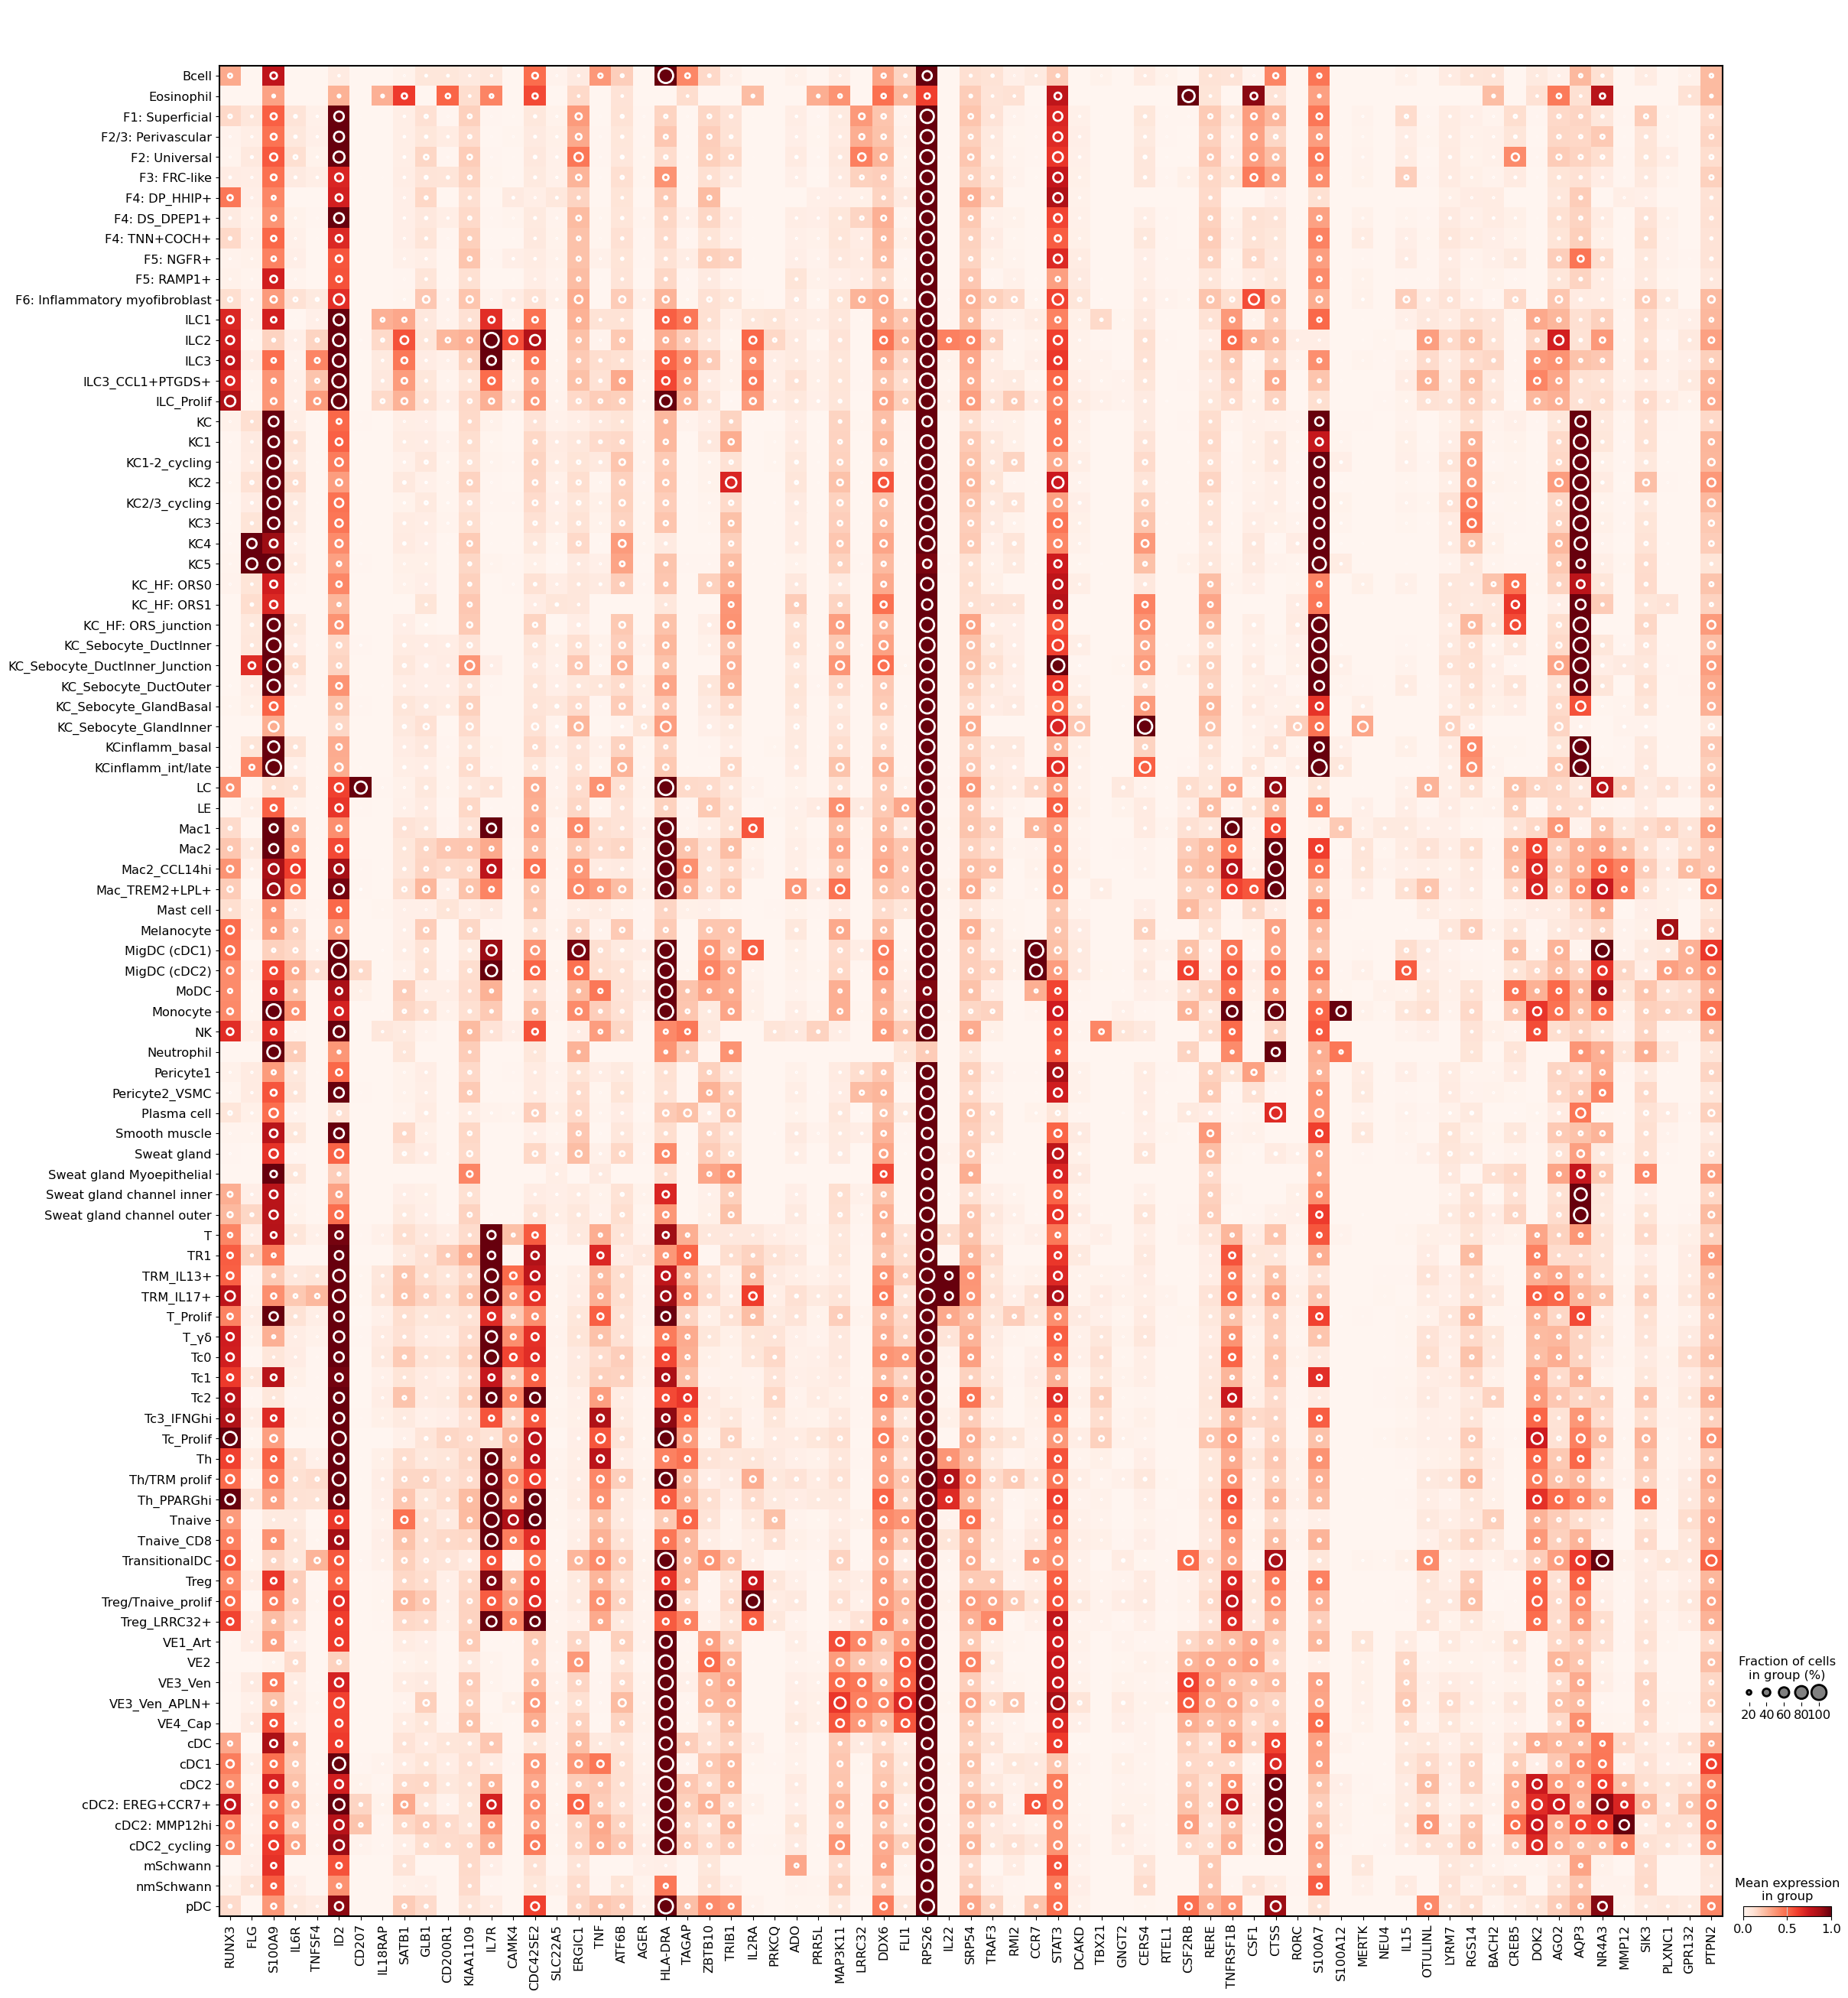

In [12]:
adata_i=adata[adata.obs["atlas_status_simple"]=="Eczema_Lesional"]
counts = adata_i.obs["lvl5_annotation"].value_counts()

# keep categories with >=10 cells
keep = counts[counts >= 10].index

# filter AnnData
adata_i = adata_i[adata_i.obs["lvl5_annotation"].isin(keep)].copy()
dp = sc.pl.DotPlot(
            adata_i, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            AD_GENES_OT,
            #swap_axes=True,
            groupby="lvl5_annotation",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
        # standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                      # dot_max=.3

                  )
#dp.show()     
dp.savefig("supp_celltypesHEATMAP_gwas_ad_scRNA.pdf", dpi=300)       
    

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

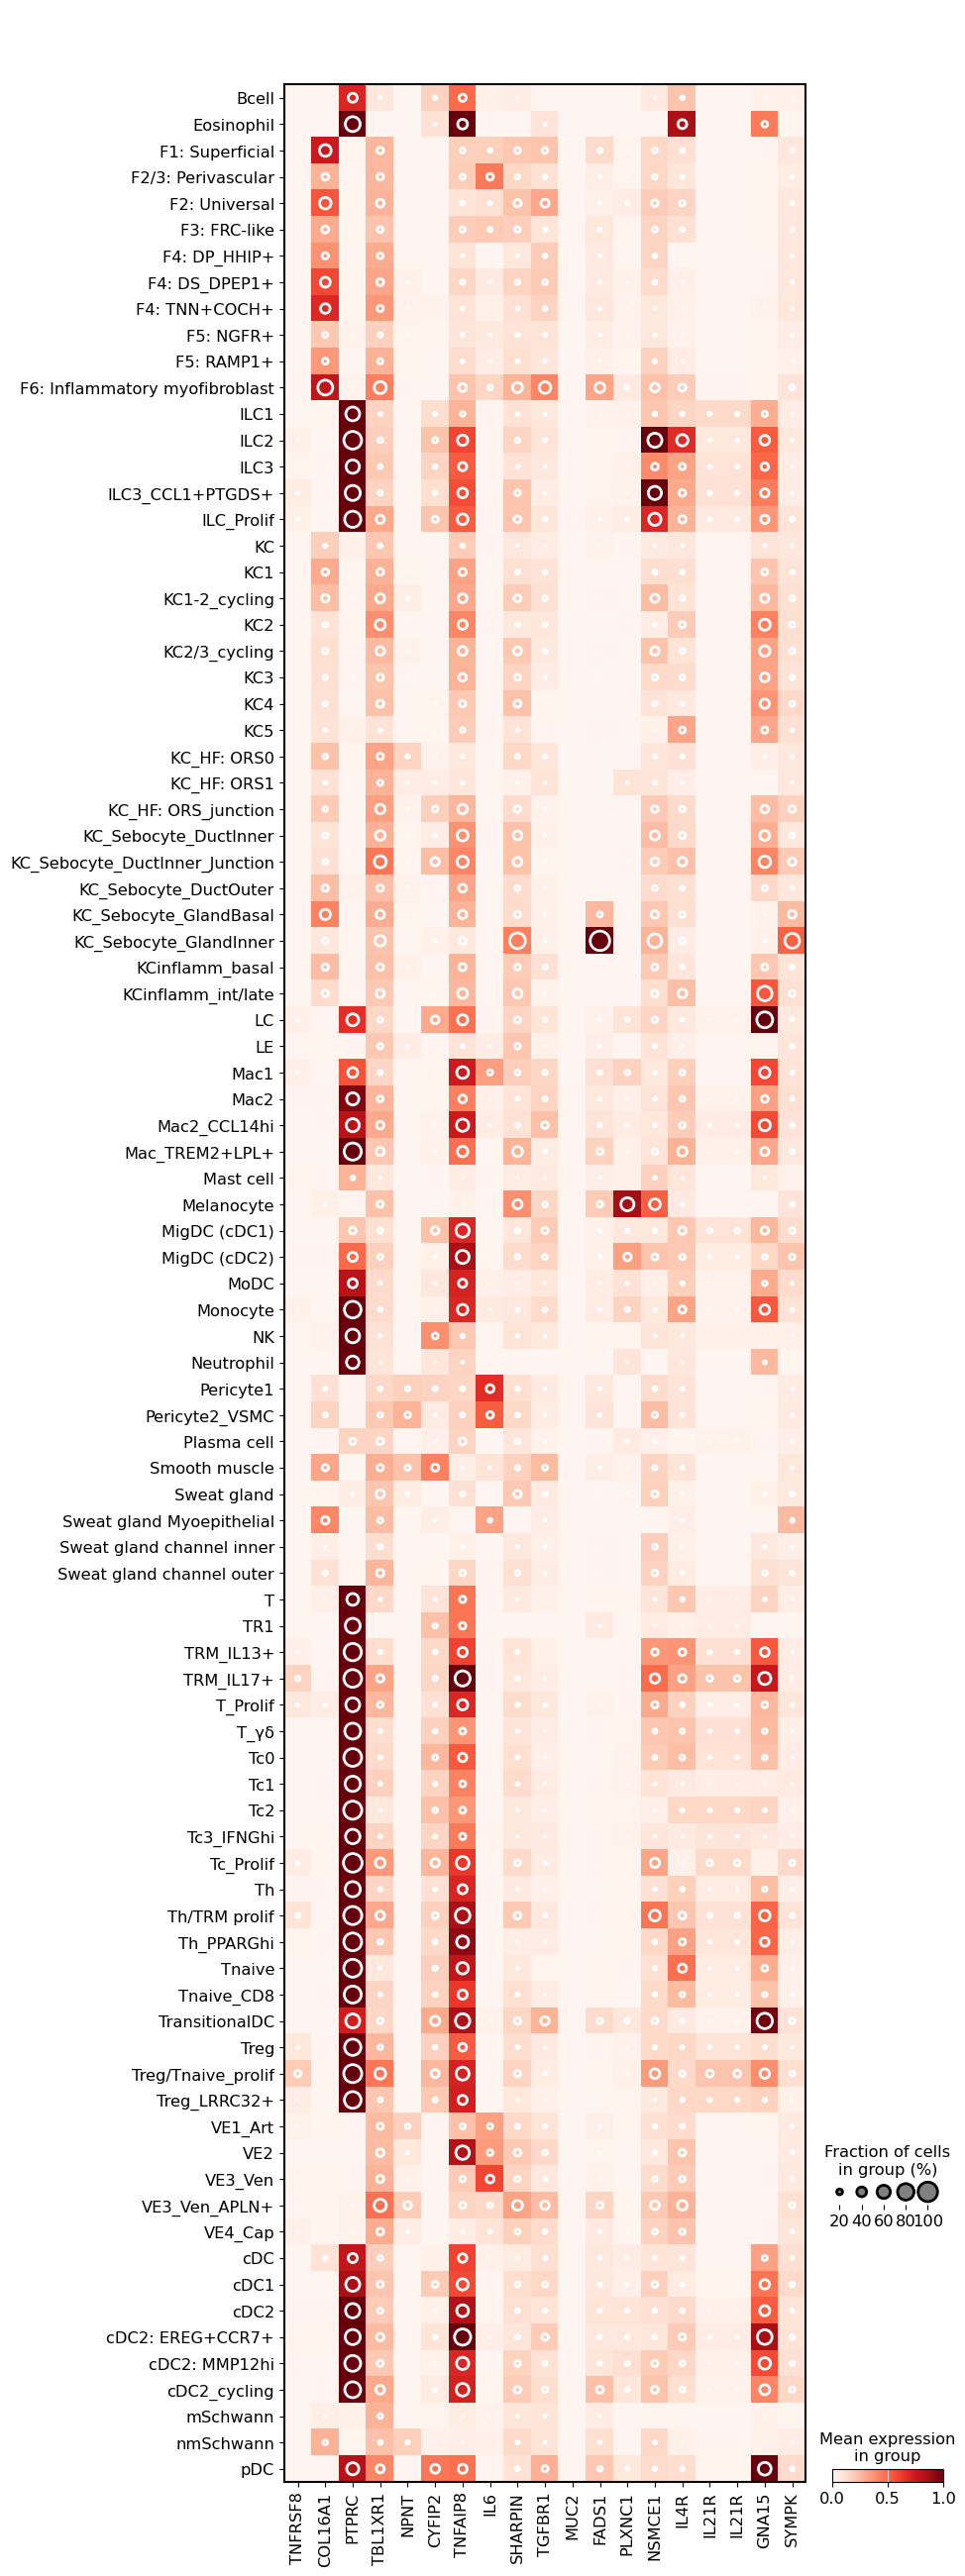

In [13]:
genes = [
    "TNFRSF8", "COL16A1", "PTPRC", "TBL1XR1", "NPNT", "CYFIP2",
    "TNFAIP8", "IL6", "SHARPIN", "TGFBR1", "MUC2", "FADS1",
    "PLXNC1", "NSMCE1", "IL4R", "IL21R", "IL21R", "GNA15", "SYMPK"
]

adata_i=adata[adata.obs["atlas_status_simple"]=="Eczema_Lesional"]
counts = adata_i.obs["lvl5_annotation"].value_counts()

# keep categories with >=10 cells
keep = counts[counts >= 10].index

# filter AnnData
adata_i = adata_i[adata_i.obs["lvl5_annotation"].isin(keep)].copy()
dp = sc.pl.DotPlot(
            adata_i, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            genes,
            #swap_axes=True,
            groupby="lvl5_annotation",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
        # standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                      # dot_max=.3

                  )
#dp.show()     
dp.savefig("supp_celltypesHEATMAP_gwas_ad_scRNA.pdf", dpi=300)       
    

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

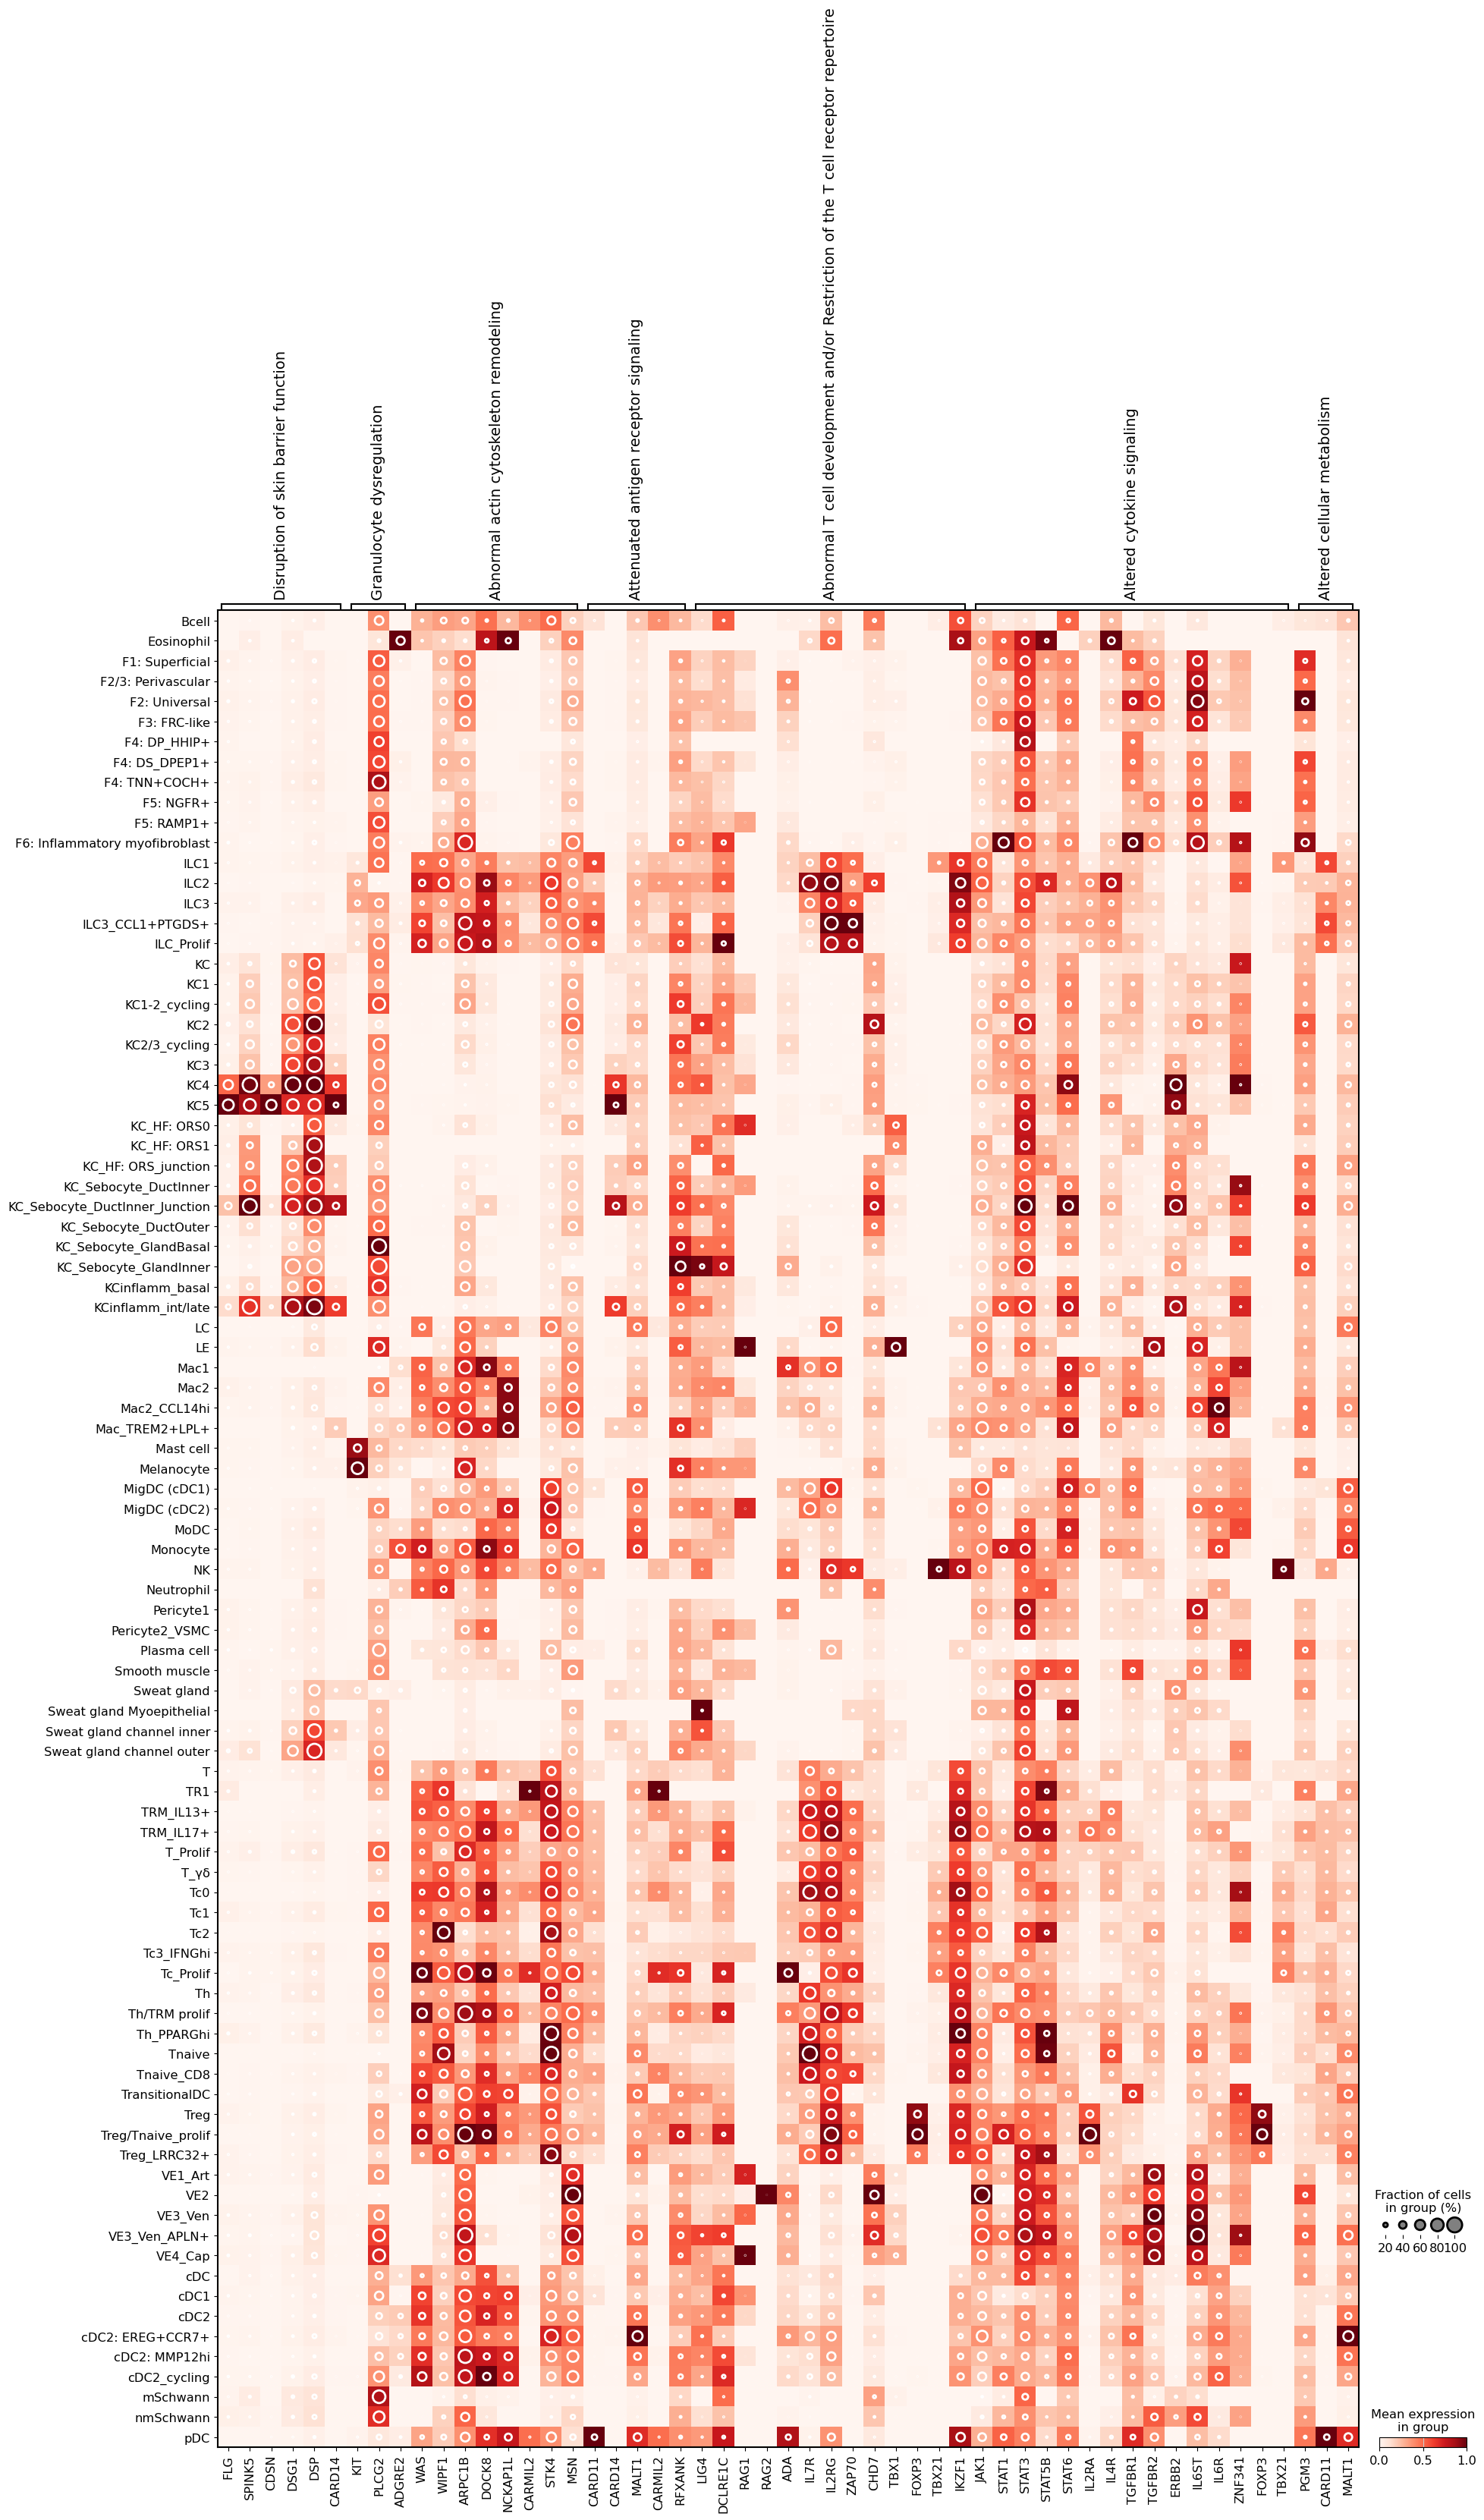

In [14]:
pathways = {
    "Disruption of skin barrier function": ["FLG", "SPINK5", "CDSN", "DSG1", "DSP", "CARD14"],
    "Granulocyte dysregulation": ["KIT", "PLCG2", "ADGRE2"],
    "Abnormal actin cytoskeleton remodeling": ["WAS", "WIPF1", "ARPC1B", "DOCK8", "NCKAP1L", "CARMIL2", "STK4", "MSN"],
    "Attenuated antigen receptor signaling": ["CARD11", "CARD14", "MALT1", "CARMIL2", "RFXANK"],
    "Abnormal T cell development and/or Restriction of the T cell receptor repertoire": ["LIG4", "DCLRE1C", "RAG1", "RAG2", "ADA",
                                                                                         "IL7R", "IL2RG", "ZAP70", "CHD7", "TBX1",
                                                                                         "FOXP3", "TBX21", "IKZF1"],
    "Altered cytokine signaling": ["JAK1", "STAT1", "STAT3",  "STAT5B",  "STAT6", "IL2RA", 
                                   "IL4R", "TGFBR1", "TGFBR2", "ERBB2",
                                   "IL6ST", "IL6R", "ZNF341", "FOXP3", "TBX21"],
    "Altered cellular metabolism": ["PGM3", "CARD11", "MALT1"],
}

dp = sc.pl.DotPlot(
            adata_i, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            pathways,
            #swap_axes=True,
            groupby="lvl5_annotation",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
         standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                      # dot_max=.3

                  )
dp.show()     

In [15]:
adata.obs["atlas_status_simple"].value_counts()

atlas_status_simple
Eczema_Lesional                                   190291
Psoriasis_Lesional                                145006
Psoriasis_PostRx                                   96485
Eczema_Nonlesional                                 92297
Eczema_PostRx                                      10920
Healthy_Nonlesional_prurigo_calugura_GSE213849      2490
Eczema_Lesional_prurigo_calugura_GSE213849          1400
Name: count, dtype: int64

In [16]:
adata.obs["lvl5_annotation2"] = adata.obs["lvl5_annotation"].astype(str) + "_" +  adata.obs["atlas_status_simple"].astype(str) 
adata_i=adata[(adata.obs["atlas_status_simple"]=="Eczema_Lesional")|
             (adata.obs["atlas_status_simple"]=="Psoriasis_Lesional")
             ]


In [17]:
# dp = sc.pl.DotPlot(
#             adata_i, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
#             genes
#             #swap_axes=True,
#             groupby="lvl5_annotation2",
#            vmax=1,
#             #    colorbar_title='Mean expression\n(variance scaled)', 
#          standard_scale="var",
#            # save="5g_AD.pdf",
#         ) 
# dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
#                  # swap_axes=True,

#                       # dot_max=.3

#                   )
# dp.show()     

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(lev

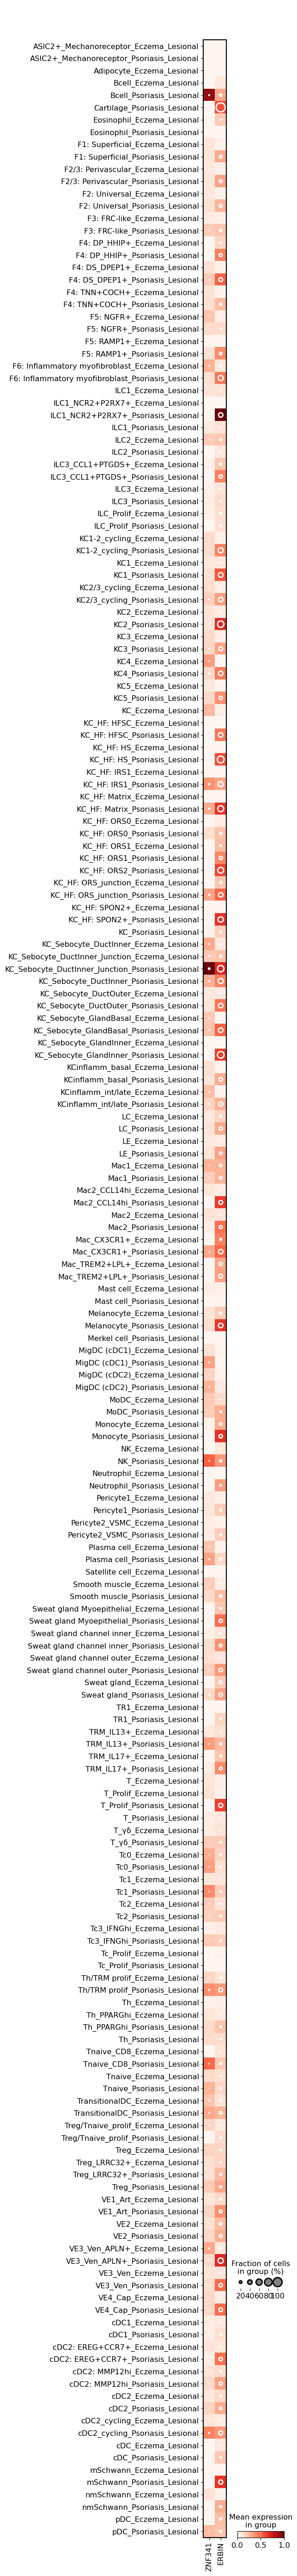

In [18]:
dp = sc.pl.DotPlot(
            adata_i, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            ["ZNF341", "ERBIN"],
            #swap_axes=True,
            groupby="lvl5_annotation2",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
         standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                 # swap_axes=True,

                      # dot_max=.3

                  )
dp.show()     

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

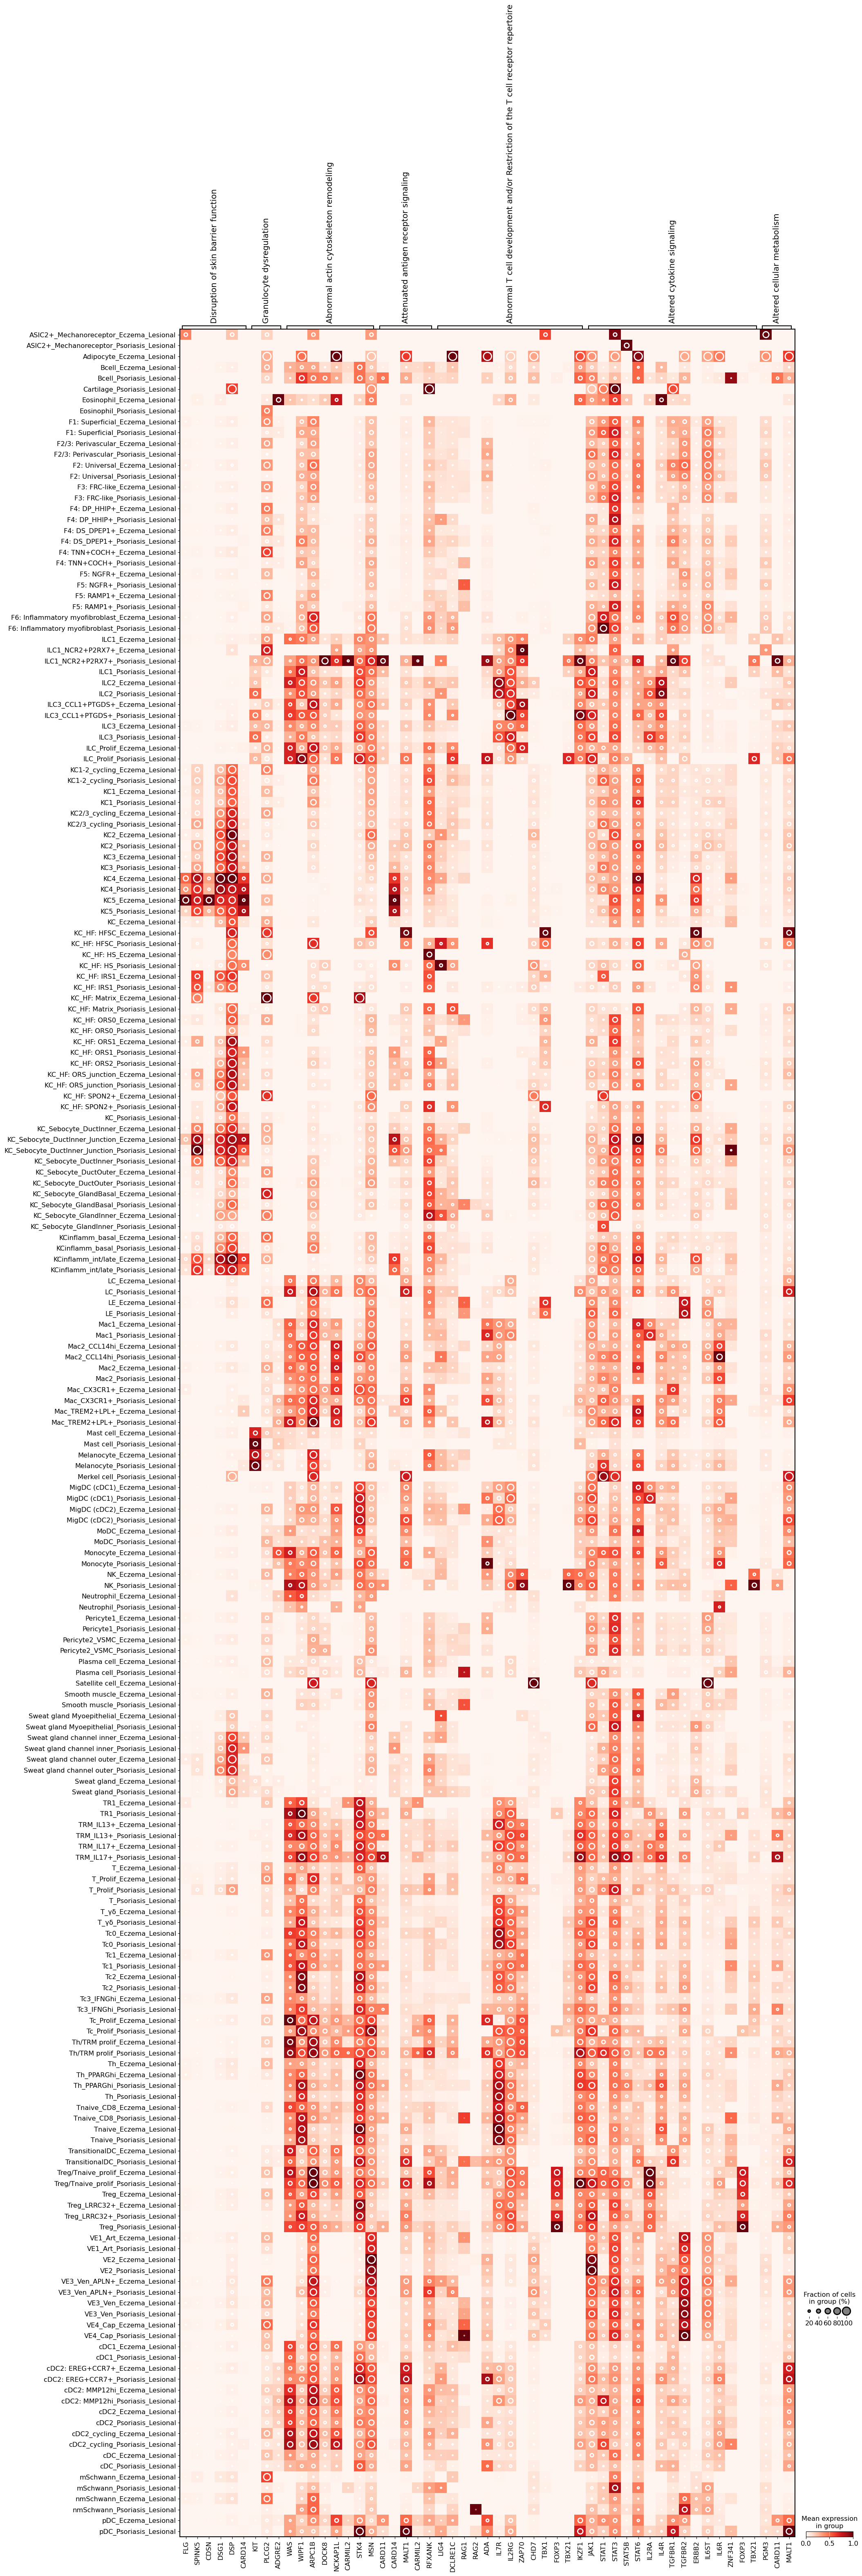

In [19]:
pathways = {
    "Disruption of skin barrier function": ["FLG", "SPINK5", "CDSN", "DSG1", "DSP", "CARD14"],
    "Granulocyte dysregulation": ["KIT", "PLCG2", "ADGRE2"],
    "Abnormal actin cytoskeleton remodeling": ["WAS", "WIPF1", "ARPC1B", "DOCK8", "NCKAP1L", "CARMIL2", "STK4", "MSN"],
    "Attenuated antigen receptor signaling": ["CARD11", "CARD14", "MALT1", "CARMIL2", "RFXANK"],
    "Abnormal T cell development and/or Restriction of the T cell receptor repertoire": ["LIG4", "DCLRE1C", "RAG1", "RAG2", "ADA",
                                                                                         "IL7R", "IL2RG", "ZAP70", "CHD7", "TBX1",
                                                                                         "FOXP3", "TBX21", "IKZF1"],
    "Altered cytokine signaling": ["JAK1", "STAT1", "STAT3",  "STAT5B",  "STAT6", "IL2RA", 
                                   "IL4R", "TGFBR1", "TGFBR2", "ERBB2",
                                   "IL6ST", "IL6R", "ZNF341", "FOXP3", "TBX21"],
    "Altered cellular metabolism": ["PGM3", "CARD11", "MALT1"],
}

dp = sc.pl.DotPlot(
            adata_i, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            pathways,
            #swap_axes=True,
            groupby="lvl5_annotation2",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
         standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                      # dot_max=.3

                  )
dp.show()     

In [20]:
stop

NameError: name 'stop' is not defined

In [ ]:
1

In [ ]:
psoriasis_genes = [
    
    "IL23R",
    "FSD1",
    "FUT2",
    "STAP2",
    "CPVL",
    "POU2F3",
    "TRAF3IP2",
    "TYK2",
     "SH2B3",
    "ERAP1",
    "CARD14",
    
    
    "PARK7", "ERRFI1", "PLOD1", "RUNX3", "IL12RB2", "LCE3C", "KPRP", "CRB1",
    "PTPRC", "KDM5B", "CYB5R1", "POMC", "NRBP1", "PUS10", "C2ORF74", "AHSA2",
    "B3GNT2", "ACOXL", "KCNH7", "PLCL2", "CEP97", "ZPLD1", "LEKR1", "TP63",
    "CCNA2", "IL7R", "CAST", "HINT1", "SLC22A4", "CSF1R", "FGFR4", "IRF4",
    "CDKAL1", "SLC17A3", "SLC17A2", "PSMB9", "ITPR3", "GRM4", "BEND3", "FYN",
    "IFNGR1", "TAGAP", "ELMO1", "MYC", "ACO1", "DDX58", "NDUFB6", "FAM206A",
    "IL2RA", "PLAU", "ADK", "ZMIZ1", "PPIF", "PRR5L", "RPS6KA4", "ESRRA",
    "MAP3K11", "ZC3H12C", "GRIK4", "ETS1", "KCNJ1", "ERBB3", "COG6", "FOXO1",
    "PSMA6", "ATP10A", "KLF13", "CLEC16A", "RMI2", "CTD-3088G3.8", "ITGAX",
    "LGALS9", "KCNH4", "HSD17B1", "PHOSPHO1", "GALK1", "CARD14", "SGSH",
    "TUBB6", "PTPN2", "POLI", "STARD6", "TYK2", "S1PR5", "DNMT3B", "PTPN1",
    "IFNAR1", "RUNX1", "PPIL2"
]
adata_i=adata[adata.obs["atlas_status_simple"]=="Psoriasis_Lesional"]
counts = adata_i.obs["lvl5_annotation"].value_counts()

# keep categories with >=10 cells
keep = counts[counts >= 10].index

# filter AnnData


psoriasis_genes = [x for x in psoriasis_genes if x not in ['AHSA2', 'C2ORF74', 'CTD-3088G3.8', 'FAM206A']]


adata_i = adata_i[adata_i.obs["lvl5_annotation"].isin(keep)].copy()
dp = sc.pl.DotPlot(
            adata_i, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            psoriasis_genes,
            #swap_axes=True,
            groupby="lvl5_annotation",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
        # standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                      # dot_max=.3

                  )
#dp.show()     
dp.savefig("supp_celltypesHEATMAP_gwas_psoriasis_scRNA.pdf", dpi=300)       
    

# XENIUM

In [ ]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
adata=sc.read_h5ad(PATH)
adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
del(adata)
import gc
gc.collect()


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST





In [ ]:
sc.pp.normalize_total(adata_5k, target_sum=1e4)
sc.pp.log1p(adata_5k)

# AD

In [ ]:
VMAX_PLOTS = 0.8
SPOT_SIZE=40


In [ ]:

adata_5k_i=adata_5k[adata_5k.obs["disease_overall"]=="AD"]

In [ ]:
# AD_GENES_OT=  [
#     "RUNX3",
#     "FLG",
#     "S100A9",
#     "IL6R",
#     "TNFSF4",
#     "ID2",
#     "CD207",
#     "IL18RAP",
#     "SATB1",
#     "GLB1",
#     "CD200R1",
#     "KIAA1109",
#     "IL7R",
#     "CAMK4",
#     "CDC42SE2",
#     "SLC22A5",
#     "ERGIC1",
#     "TNF",
#     "ATF6B",
#     "AGER",
#     "HLA-DRA",
#     "TAGAP",
#     "ZBTB10",
#     "TRIB1",
#     "IL2RA",
#     "PRKCQ",
#     "ADO",
#     "PRR5L",
#     "MAP3K11",
#     "LRRC32",
#     "DDX6",
#     "FLI1",
#     "RPS26",
#     "IL22",
#     "SRP54",
#     "TRAF3",
#     "RMI2",
#     "CCR7",
#     "STAT3",
#     "DCAKD",
#     "TBX21",
#     "GNGT2",
#     "CERS4",
#     "RTEL1",
#     "CSF2RB",
#     "RERE",
#     "TNFRSF1B",
#     "CSF1",
#     "CTSS",
#     "RORC",
#     "S100A7",
#     "S100A12",
#    # "AHSA2P",
#     "MERTK",
#     "NEU4",
#     "IL15",
#     "OTULINL",
#     "LYRM7",
#     "RGS14",
#     "BACH2",
#     "CREB5",
#     "DOK2",
#     "AGO2",
#     "AQP3",
#     "NR4A3",
#     "MMP12",
#     "SIK3",
#     "PLXNC1",
#     "GPR132",
#     "PTPN2"
# ]
print(len(remove_markers(AD_GENES_OT)))
remove_markers(AD_GENES_OT)

In [ ]:
adata_5k_i=adata_5k_i[adata_5k_i.obs["niche19"]!="Nonspecific/folded"]
adata_5k_i=adata_5k_i[~adata_5k_i.obs["niche19"].isna()]
adata_5k_ii=adata_5k_i[adata_5k_i.obs["Site_status"]=="Lesional"]



# Get counts per niche
counts = adata_5k_ii.obs["niche19"].value_counts()

# Identify categories with at least 10 cells
valid_niches = counts[counts > 10].index

# Subset AnnData to only those categories
adata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()


In [ ]:
desired_order = [
    'Sebaceous_immune', 
    'Plasma_cell_niche','Plasma_cell_rich',
    'Tzone-like',
    'Epidermis_APChi',
    'EpidermisInflamm_late',
'EpidermisInflamm_mid',
    'Epidermis_basal_cycling',





     'Epidermis_late',
    'Epidermis_mid',
    'Epidermis_basal', #'Epidermis_mid1',
    'Papillary_dermis',
    'Small_BV', 'Large_BV','VenuleMuscle',
    'Reticular_dermis', 'Reticular_dermis_LErich','Reticular_dermis_LE_rich',
    'Muscle', 'Perineural',
    'Sebaceous_gland','Sebaceous_duct',
    'Sweat_gland', 'Sweat_gland_channel',
    'HF', 'OuterHF','HF_outer','HF_inner','HF_innermost',
    'Perifollicular_VE', 'Hypodermis'
]

count=0
for x in adata_5k_ii.obs["niche19"].unique():
    if x not in desired_order:
        print(x)
        count += 1
if count != 0: 
    stop


In [ ]:
# make sure niche12 is categorical and ordered
adata_5k_ii.obs["niche19"] = pd.Categorical(
    adata_5k_ii.obs["niche19"],
    categories=desired_order,
    ordered=True
)

In [ ]:
counts = adata_5k_ii.obs["niche19"].value_counts()

# Identify categories with at least 10 cells
valid_niches = counts[counts > 10].index

# Subset AnnData to only those categories
adata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()

In [ ]:
adata_5k_ii.obs["Site_status"].unique()

In [ ]:
KEEP = ['Lesional', 'Week 12', '3D_Lesional_baseline', '3D_Week12']
adata_5k_ii=adata_5k_ii[adata_5k_ii.obs["Site_status"].isin(KEEP)]
adata_5k_ii.obs["Site_status_simple"].value_counts()

In [ ]:
{x:x for x in adata_5k_ii.obs["Site_status"].unique()}

In [ ]:
RENAME = {'Lesional': 'Lesional',
 'Week 12': 'Week 12',
 '3D_Lesional_baseline': 'Lesional',
 '3D_Week12': 'Week 12'}
adata_5k_ii.obs["Site_status_simple"]=adata_5k_ii.obs["Site_status"].map(RENAME)

In [ ]:
dp = sc.pl.DotPlot(
            adata_5k_ii, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            remove_markers(AD_GENES_OT),#[:40],
            #swap_axes=True,
            groupby="niche19",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
         standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                       dot_max=.3

                  )
#dp.show()     
dp.savefig("supp_celltypesHEATMAP_gwas_ad.pdf", dpi=300)       
    

In [ ]:
CONTROL_SIZE = 1000 #
N_BINS=25  
adata_5k_i = sc.tl.score_genes(adata_5k_i, remove_markers(AD_GENES_OT), ctrl_size=CONTROL_SIZE, n_bins=N_BINS, copy=True, score_name="ad_gwas")



In [ ]:
import pickle

# Path to your pickle file
path = "/nfs/team298/ls34/niche_colors.pkl"

# Load the dictionary
with open(path, "rb") as f:
    colors_new2 = pickle.load(f)

In [ ]:
# Count cells per niche
counts = adata_5k_i.obs["niche19"].value_counts()

# Keep only niches with >=10 cells
valid_niches = counts[counts >= 10].index

# Subset AnnData
adata_5k_i = adata_5k_i[adata_5k_i.obs["niche19"].isin(valid_niches)].copy()

# Clean up unused categories
adata_5k_i.obs["niche19"] = adata_5k_i.obs["niche19"].cat.remove_unused_categories()



In [ ]:

# Extract the obs as DataFrame
df = adata_5k_i.obs[["niche19", "ad_gwas"]].copy()

# Compute mean per niche and sort descending
order = (
    df.groupby("niche19")["ad_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Make violin plot
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="niche19",
    y="ad_gwas",
    order=order,
    inner="box",   # optional: show a mini boxplot inside
    cut=0,         # don’t extend violins beyond observed data
    scale="width" , # makes widths comparable
    palette=colors_new2  
)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("AD GWAS score")
plt.title("")
plt.tight_layout()
plt.savefig("9b_ad_violin_GWAS.pdf", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
COLOR_PICKLE_PATH= '/nfs/team298/ls34/color_for_adult_skin2.pkl'
# # Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

In [ ]:

# Extract the obs as DataFrame
df = adata_5k_i.obs[["lvl5_annotation", "ad_gwas"]].copy()

# Compute mean per niche and sort descending
order = (
    df.groupby("lvl5_annotation")["ad_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Make violin plot
plt.figure(figsize=(20, 5))
sns.violinplot(
    data=df,
    x="lvl5_annotation",
    y="ad_gwas",
    order=order,
    inner="box",   # optional: show a mini boxplot inside
    cut=0,         # don’t extend violins beyond observed data
    scale="width" , # makes widths comparable
        palette=colors 

)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("AD GWAS score")
plt.title(" ", )
plt.tight_layout()
plt.savefig("supp9b_ad_violin_celltype.pdf", dpi=300, bbox_inches="tight")

plt.show()

# psoriasis GWAS

In [ ]:
psoriasis_genes = [
    
    "IL23R",
    "FSD1",
    "FUT2",
    "STAP2",
    "CPVL",
    "POU2F3",
    "TRAF3IP2",
    "TYK2",
     "SH2B3",
    "ERAP1",
    "CARD14",
    
    
    "PARK7", "ERRFI1", "PLOD1", "RUNX3", "IL12RB2", "LCE3C", "KPRP", "CRB1",
    "PTPRC", "KDM5B", "CYB5R1", "POMC", "NRBP1", "PUS10", "C2ORF74", "AHSA2",
    "B3GNT2", "ACOXL", "KCNH7", "PLCL2", "CEP97", "ZPLD1", "LEKR1", "TP63",
    "CCNA2", "IL7R", "CAST", "HINT1", "SLC22A4", "CSF1R", "FGFR4", "IRF4",
    "CDKAL1", "SLC17A3", "SLC17A2", "PSMB9", "ITPR3", "GRM4", "BEND3", "FYN",
    "IFNGR1", "TAGAP", "ELMO1", "MYC", "ACO1", "DDX58", "NDUFB6", "FAM206A",
    "IL2RA", "PLAU", "ADK", "ZMIZ1", "PPIF", "PRR5L", "RPS6KA4", "ESRRA",
    "MAP3K11", "ZC3H12C", "GRIK4", "ETS1", "KCNJ1", "ERBB3", "COG6", "FOXO1",
    "PSMA6", "ATP10A", "KLF13", "CLEC16A", "RMI2", "CTD-3088G3.8", "ITGAX",
    "LGALS9", "KCNH4", "HSD17B1", "PHOSPHO1", "GALK1", "CARD14", "SGSH",
    "TUBB6", "PTPN2", "POLI", "STARD6", "TYK2", "S1PR5", "DNMT3B", "PTPN1",
    "IFNAR1", "RUNX1", "PPIL2"
]
seen=[]
newli=[]
for x in psoriasis_genes:
    if x not in seen:
        newli.append(x)
        seen.append(x)
    else:
        continue
psoriasis_genes=remove_markers(newli)



In [ ]:
adata_5k_i=adata_5k[adata_5k.obs["disease_overall"]=="Psoriasis"]
adata_5k_i.shape

In [ ]:
adata_5k_i=adata_5k_i[adata_5k_i.obs["niche19"]!="Nonspecific/folded"]
adata_5k_i=adata_5k_i[~adata_5k_i.obs["niche19"].isna()]
adata_5k_ii=adata_5k_i[adata_5k_i.obs["Site_status"]=="Lesional"]



In [ ]:
count=0
for x in adata_5k_i.obs["niche19"].unique():
    if x not in desired_order:
        print(x)
        count = count+1
if count != 0: 
    stop


In [ ]:
adata_5k_ii.obs["niche19"] = pd.Categorical(
    adata_5k_ii.obs["niche19"],
    categories=desired_order,
    ordered=True
)



In [ ]:
counts = adata_5k_ii.obs["niche19"].value_counts()
valid_niches = counts[counts > 10].index
adata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()


In [ ]:
dp = sc.pl.DotPlot(
        adata_5k_ii,
        remove_markers(psoriasis_genes)[:30],
        #swap_axes=True,
        groupby="niche19",
       vmax=1,
        #    colorbar_title='Mean expression\n(variance scaled)', 
     standard_scale="var",

    ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                   dot_max=.3

              )

dp.savefig("supp_celltypesHEATMAP_gwas_pso.pdf", dpi=300)       


In [ ]:
CONTROL_SIZE = 1000 #
N_BINS=25  
adata_5k_ii = sc.tl.score_genes(adata_5k_ii, remove_markers(psoriasis_genes), ctrl_size=CONTROL_SIZE, n_bins=N_BINS, copy=True, score_name="pso_gwas")



In [ ]:
df = adata_5k_ii.obs[["niche19", "pso_gwas"]].copy()

order = (
    df.groupby("niche19")["pso_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="niche19",
    y="pso_gwas",
    order=order,
    inner="box",    
    cut=0,       
    scale="width" ,  
    palette=colors_new2  ,

)

plt.xticks(rotation=90)
plt.xlabel("Niche")
plt.ylabel("PSO GWAS score")
plt.title("")
plt.tight_layout()
plt.savefig("supp9b_pso_violin_GWAS.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
df = adata_5k_ii.obs[["lvl5_annotation", "pso_gwas"]].copy()

order = (
    df.groupby("lvl5_annotation")["pso_gwas"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(20, 5))
sns.violinplot(
    data=df,
    x="lvl5_annotation",
    y="pso_gwas",
    order=order,
    inner="box",   
    cut=0,        
    scale="width",  
                palette=colors 

)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("PSO GWAS score")
plt.title("")
plt.tight_layout()

plt.savefig("supp9b_PSO_violin_celltype.pdf", dpi=300, bbox_inches="tight")
plt.show()